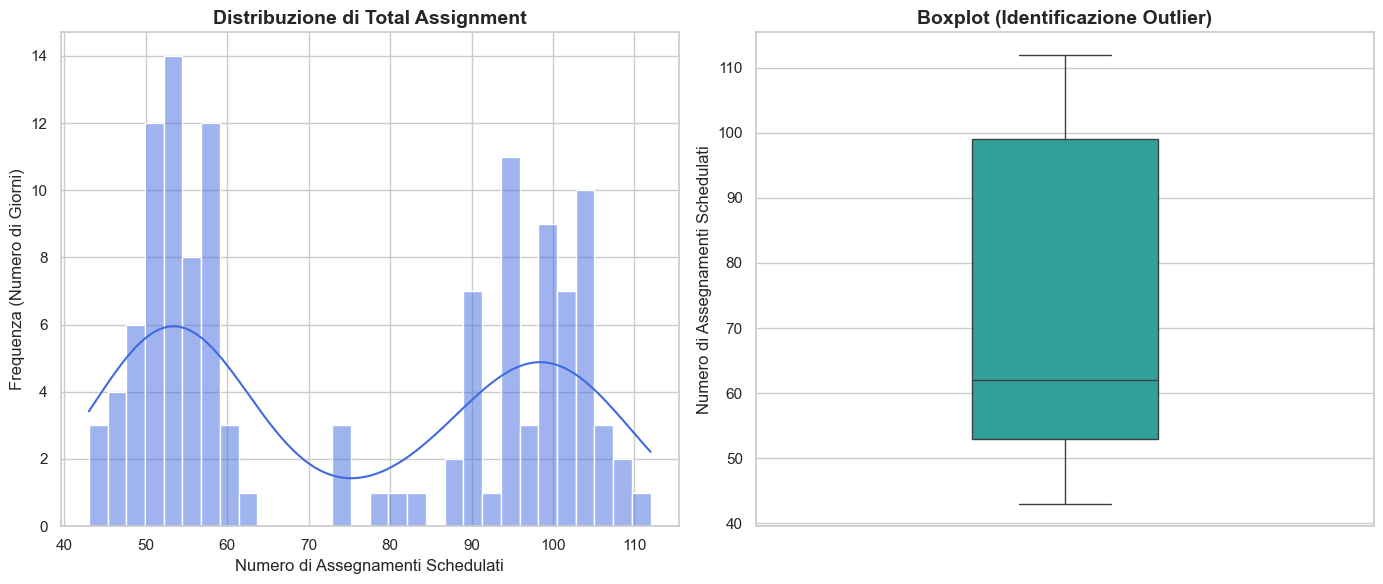

Statistiche Descrittive per Total Assignment:
count    125.000000
mean      74.704000
std       22.798919
min       43.000000
25%       53.000000
50%       62.000000
75%       99.000000
max      112.000000
Name: totalAssignments, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/cleaned_dataset.csv")

target_col = "totalAssignments"

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df, x=target_col, kde=True, ax=axes[0], color="royalblue", bins=30)
axes[0].set_title("Distribuzione di Total Assignment", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Numero di Assegnamenti Schedulati", fontsize=12)
axes[0].set_ylabel("Frequenza (Numero di Giorni)", fontsize=12)

sns.boxplot(data=df, y=target_col, ax=axes[1], color="lightseagreen", width=0.3)
axes[1].set_title("Boxplot (Identificazione Outlier)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Numero di Assegnamenti Schedulati", fontsize=12)

plt.tight_layout()
plt.show()

print("Statistiche Descrittive per Total Assignment:")
print(df[target_col].describe())

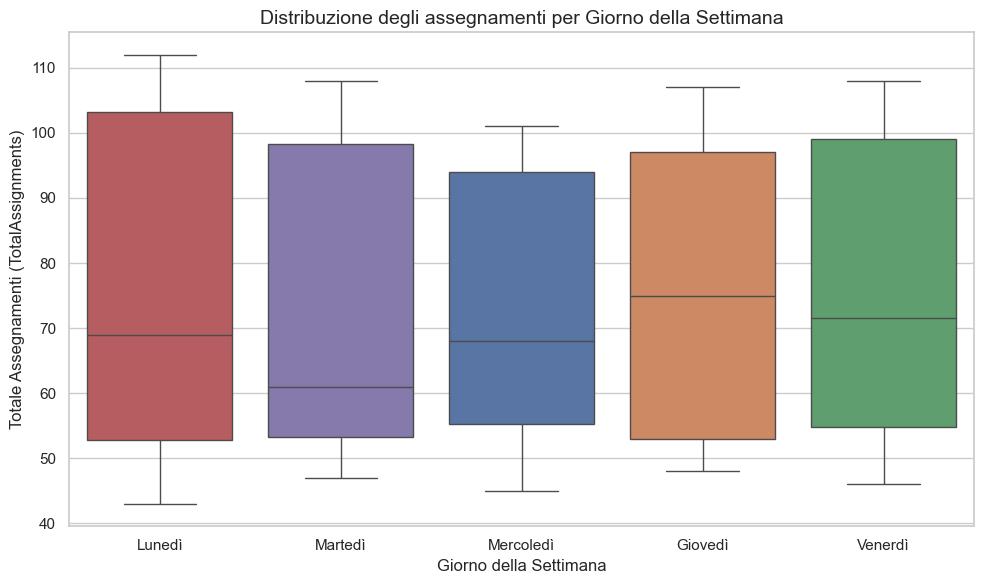

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df = pd.read_csv("./data/cleaned_dataset.csv")

day_map = {0: "Lunedì", 1: "Martedì", 2: "Mercoledì", 3: "Giovedì", 4: "Venerdì"}
df["Nome_Giorno"] = df["dayOfWeek"].map(day_map)

ordine_giorni = ["Lunedì", "Martedì", "Mercoledì", "Giovedì", "Venerdì"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Nome_Giorno",
    y="totalAssignments",
    order=ordine_giorni,
    ax=ax,
    hue="Nome_Giorno",
)

ax.set_title("Distribuzione degli assegnamenti per Giorno della Settimana", fontsize=14)
ax.set_xlabel("Giorno della Settimana", fontsize=12)
ax.set_ylabel("Totale Assegnamenti (TotalAssignments)", fontsize=12)

plt.tight_layout()
plt.show()

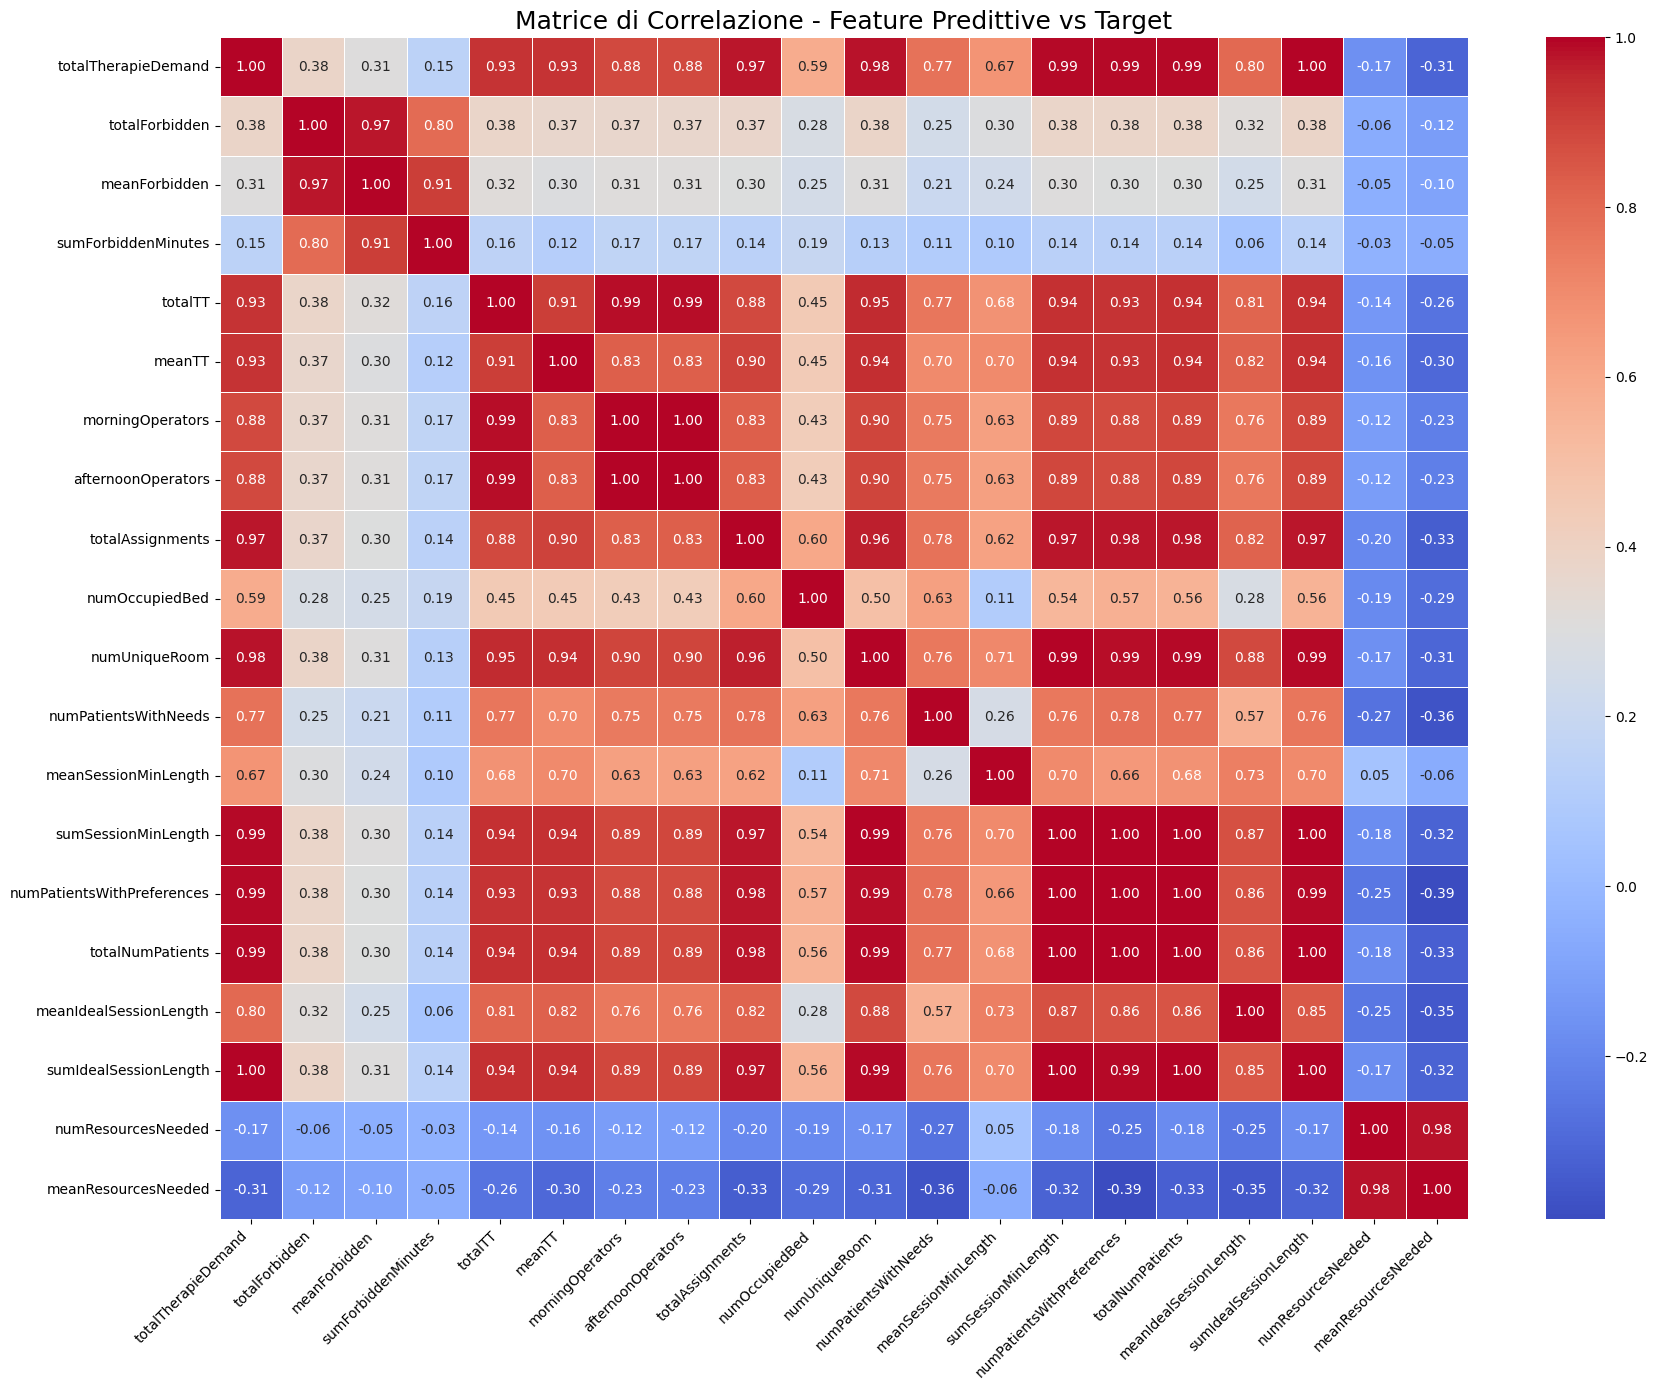

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/cleaned_dataset.csv")

df_clean = df.drop(columns=["dayOfWeek", "month", "planningDate_dt", "Unnamed: 0"])

matrice_corr = df_clean.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Matrice di Correlazione - Feature Predittive vs Target", fontsize=18)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

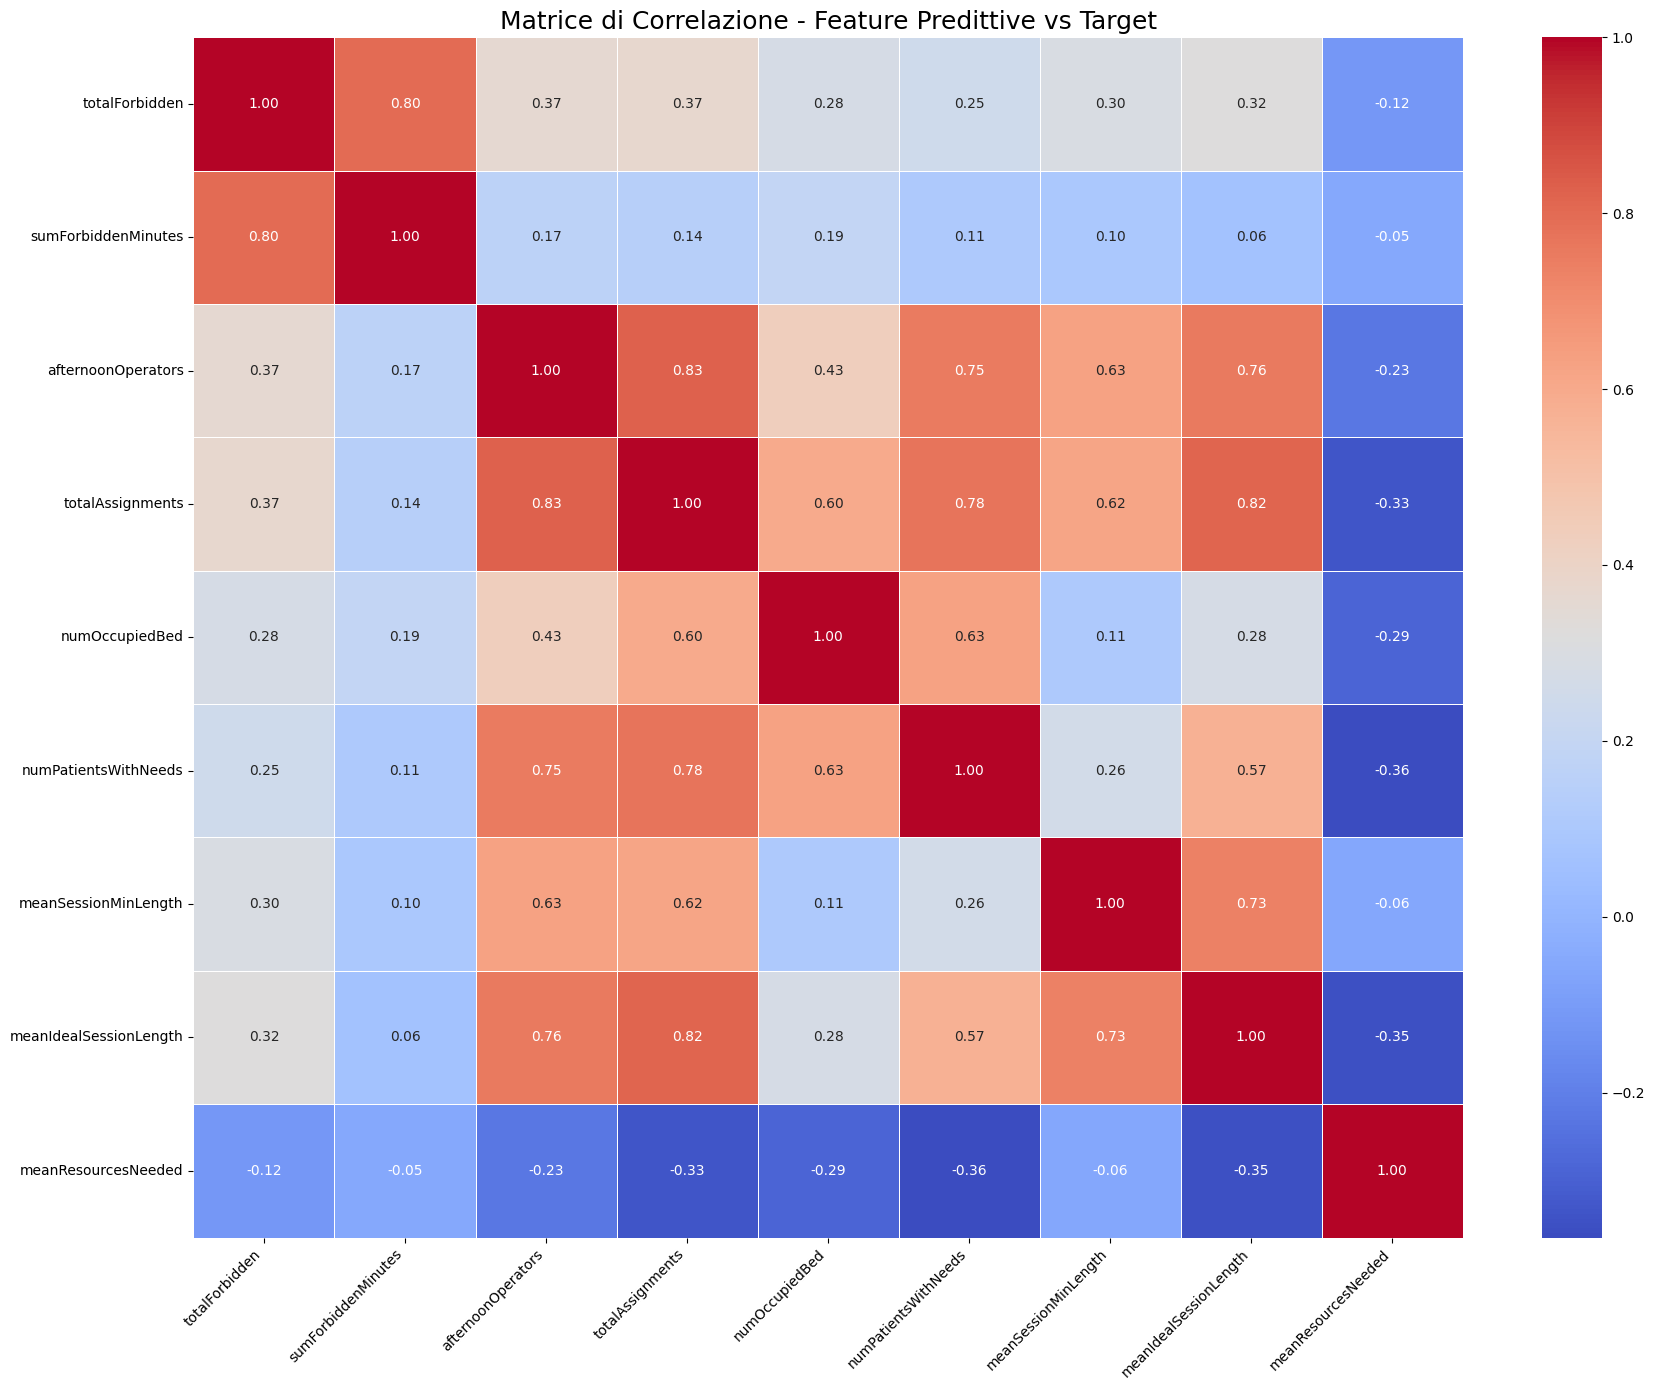

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/cleaned_dataset.csv")
df_copy = df.copy()

df_copy.drop(
    columns=["planningDate_dt", "Unnamed: 0", "month", "dayOfWeek"], inplace=True
)
df_clean = df.drop(columns=["dayOfWeek", "month", "planningDate_dt", "Unnamed: 0"])
corr_target = df_copy.corr()["totalAssignments"].abs().sort_values(ascending=False)

matrice_corr = df_clean.corr()

columns_to_be_dropped = set()
columns = matrice_corr.columns

for i in range(len(columns)):
    col_a = columns[i]

    if col_a in columns_to_be_dropped:
        continue

    for j in range(i + 1, len(columns)):
        col_b = columns[j]

        if matrice_corr.loc[col_a, col_b] >= 0.90:

            corr_of_a = corr_target.loc[col_a]
            corr_of_b = corr_target.loc[col_b]

            if corr_of_a > corr_of_b:
                columns_to_be_dropped.add(col_b)
            else:
                columns_to_be_dropped.add(col_a)
                break

plt.figure(figsize=(18, 14))

df_clean.drop(columns=columns_to_be_dropped, inplace=True)
matrice_corr = df_clean.corr()

sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

df_clean.to_csv("./data/dataset_finale.csv", index=False)

plt.title("Matrice di Correlazione - Feature Predittive vs Target", fontsize=18)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

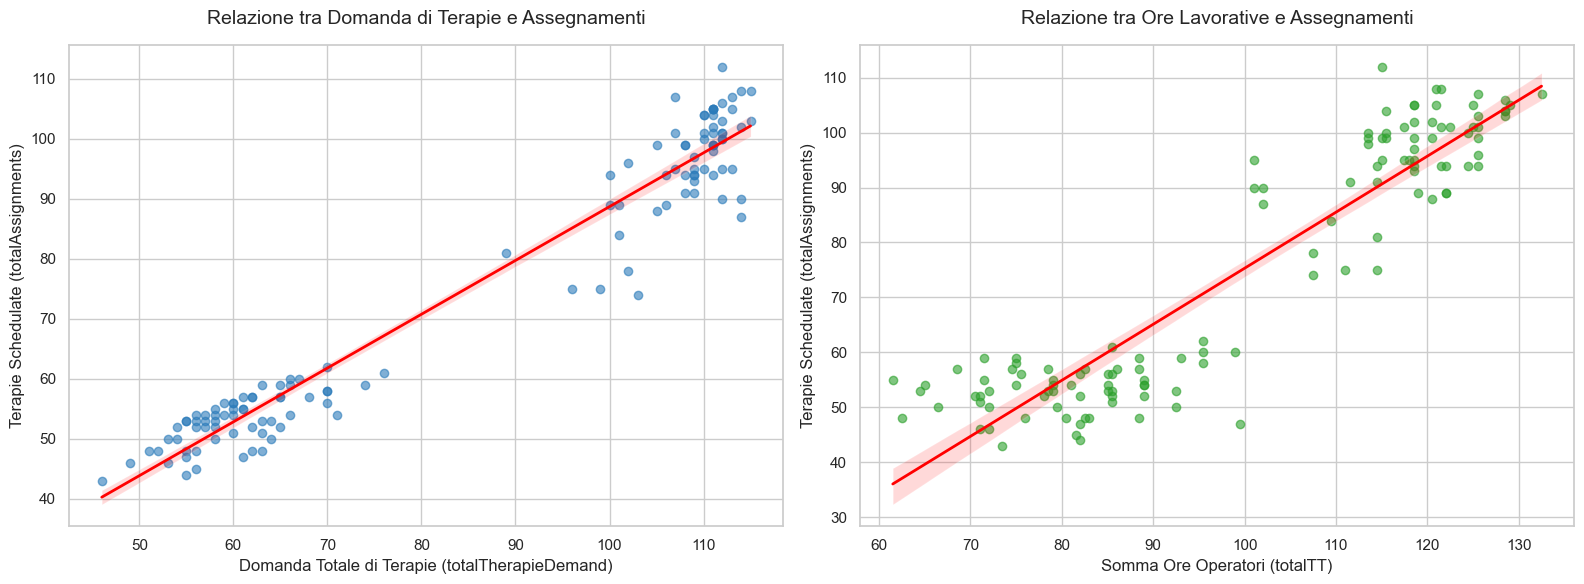

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    data=df_clean,
    x="totalTherapieDemand",
    y="totalAssignments",
    ax=axes[0],
    scatter_kws={"alpha": 0.6, "color": "#2b7bba"},
    line_kws={"color": "red", "linewidth": 2},
)
axes[0].set_title(
    "Relazione tra Domanda di Terapie e Assegnamenti", fontsize=14, pad=15
)
axes[0].set_xlabel("Domanda Totale di Terapie (totalTherapieDemand)", fontsize=12)
axes[0].set_ylabel("Terapie Schedulate (totalAssignments)", fontsize=12)


sns.regplot(
    data=df_clean,
    x="totalTT",
    y="totalAssignments",
    ax=axes[1],
    scatter_kws={"alpha": 0.6, "color": "#2ca02c"},
    line_kws={"color": "red", "linewidth": 2},
)
axes[1].set_title("Relazione tra Ore Lavorative e Assegnamenti", fontsize=14, pad=15)
axes[1].set_xlabel("Somma Ore Operatori (totalTT)", fontsize=12)
axes[1].set_ylabel("Terapie Schedulate (totalAssignments)", fontsize=12)

plt.tight_layout()
plt.show()